In [1]:
from pathlib import Path
import sys


def find_project_root(start_path: Path) -> Path:
    """Find the project directory containing src/ and notebooks/."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (
            (candidate / "src").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\haoch\OneDrive\Desktop\ewma_covariate_shift_demo\ewma_covariate_shift_demo


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import GaussianConfig
from src.ewma import (
    SD_EWMA_Config,
    fit_sd_ewma,
    run_sd_ewma,
)

config = GaussianConfig()

In [3]:
RAW_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "gaussian_mean_shift.csv"
)

gaussian_stream = pd.read_csv(RAW_DATA_PATH)

required_columns = {
    "time",
    "x",
    "true_regime",
    "true_shift",
}

missing_columns = required_columns.difference(
    gaussian_stream.columns
)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

print(f"Loaded: {RAW_DATA_PATH}")
print(f"Shape: {gaussian_stream.shape}")

gaussian_stream.head()

Loaded: C:\Users\haoch\OneDrive\Desktop\ewma_covariate_shift_demo\ewma_covariate_shift_demo\data\raw\gaussian_mean_shift.csv
Shape: (1000, 4)


,time,x,true_regime,true_shift
0,0,0.304717,before_shift,0
1,1,-1.039984,before_shift,0
2,2,0.750451,before_shift,0
3,3,0.940565,before_shift,0
4,4,-1.951035,before_shift,0


In [4]:
training_data = (
    gaussian_stream[
        gaussian_stream["true_regime"] == "before_shift"
    ]
    .copy()
)

testing_data = (
    gaussian_stream[
        gaussian_stream["true_regime"] != "before_shift"
    ]
    .copy()
)

if training_data.empty:
    raise ValueError("The training dataset is empty.")

if testing_data.empty:
    raise ValueError("The testing dataset is empty.")

print(f"Training observations: {len(training_data)}")
print(f"Testing observations: {len(testing_data)}")
print(
    "True shift time:",
    gaussian_stream.loc[
        gaussian_stream["true_shift"] == 1,
        "time",
    ].tolist(),
)

Training observations: 500
Testing observations: 500
True shift time: [500]


In [5]:
training_result = fit_sd_ewma(
    training_data["x"].to_numpy()
)

training_result

EWMATrainingResult(lambda_value=0.01, initial_z=-0.013126150466933885, final_z=-0.012403811131669452, error_variance=0.9273537635689583, error_standard_deviation=0.9629920890479622)

In [6]:
detector_config = SD_EWMA_Config(
    lambda_value=training_result.lambda_value,
    variance_smoothing=0.05,
    control_limit_multiplier=3.0,
)

stage_1_results = run_sd_ewma(
    values=testing_data["x"].to_numpy(),
    times=testing_data["time"].to_numpy(),
    initial_z=training_result.final_z,
    initial_error_variance=training_result.error_variance,
    config=detector_config,
)

stage_1_results.head()

,time,x,prediction,ewma,error,lcl,ucl,stage_1_alarm
0,500,3.363862,-0.012404,0.021359,3.376266,-2.901380,2.876572,1
1,501,2.895185,0.021359,0.050097,2.873826,-3.592296,3.635014,0
2,502,1.280520,0.050097,0.062401,1.230423,-3.965133,4.065327,0
3,503,0.497497,0.062401,0.066752,0.435095,-3.937254,4.062056,0
4,504,-0.964529,0.066752,0.056439,-1.031281,-3.842540,3.976045,0


In [7]:
stage_1_results = stage_1_results.merge(
    testing_data[
        [
            "time",
            "true_regime",
            "true_shift",
        ]
    ],
    on="time",
    how="left",
)

stage_1_results.head()

,time,x,prediction,ewma,error,lcl,ucl,stage_1_alarm,true_regime,true_shift
0,500,3.363862,-0.012404,0.021359,3.376266,-2.901380,2.876572,1,after_shift,1
1,501,2.895185,0.021359,0.050097,2.873826,-3.592296,3.635014,0,after_shift,0
2,502,1.280520,0.050097,0.062401,1.230423,-3.965133,4.065327,0,after_shift,0
3,503,0.497497,0.062401,0.066752,0.435095,-3.937254,4.062056,0,after_shift,0
4,504,-0.964529,0.066752,0.056439,-1.031281,-3.842540,3.976045,0,after_shift,0


In [8]:
shift_times = gaussian_stream.loc[
    gaussian_stream["true_shift"] == 1,
    "time",
].to_numpy()

if len(shift_times) != 1:
    raise ValueError(
        "Expected exactly one true shift point."
    )

true_shift_time = int(shift_times[0])

alarm_times = stage_1_results.loc[
    stage_1_results["stage_1_alarm"] == 1,
    "time",
].to_numpy()

false_alarm_times = alarm_times[
    alarm_times < true_shift_time
]

post_shift_alarm_times = alarm_times[
    alarm_times >= true_shift_time
]

first_detection_time = (
    int(post_shift_alarm_times[0])
    if len(post_shift_alarm_times) > 0
    else None
)

detection_delay = (
    first_detection_time - true_shift_time
    if first_detection_time is not None
    else None
)

print(f"True shift time: {true_shift_time}")
print(f"False alarms before shift: {len(false_alarm_times)}")
print(f"First post-shift alarm: {first_detection_time}")
print(f"Detection delay: {detection_delay}")

True shift time: 500
False alarms before shift: 0
First post-shift alarm: 500
Detection delay: 0


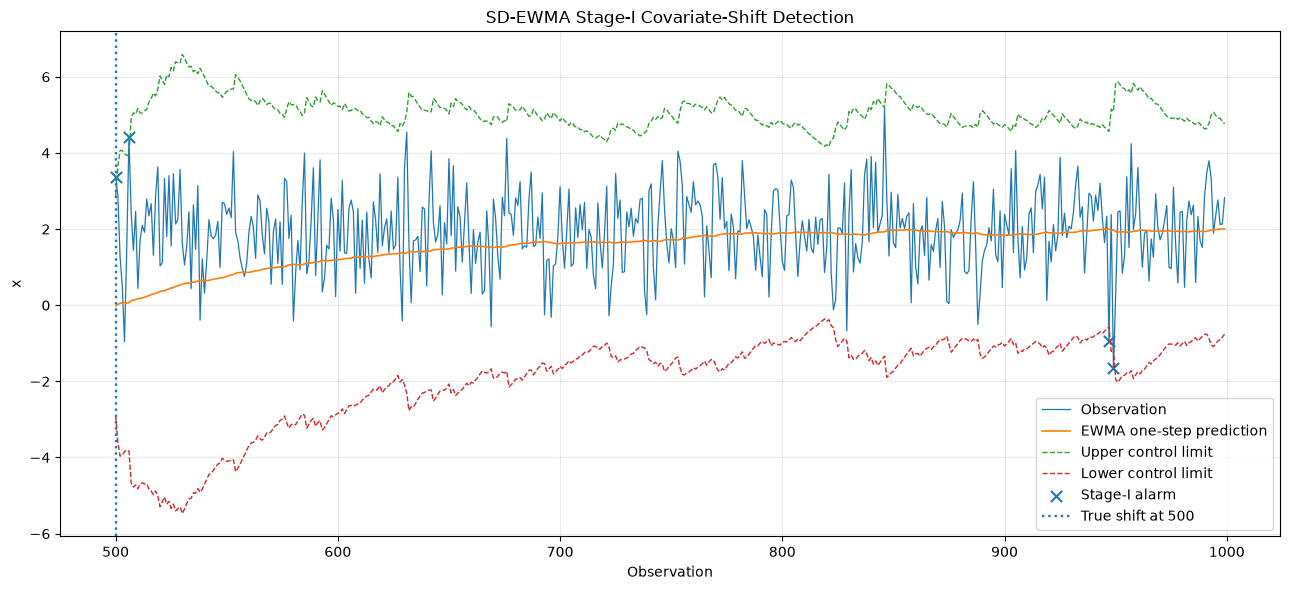

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    stage_1_results["time"],
    stage_1_results["x"],
    linewidth=0.9,
    label="Observation",
)

ax.plot(
    stage_1_results["time"],
    stage_1_results["prediction"],
    linewidth=1.2,
    label="EWMA one-step prediction",
)

ax.plot(
    stage_1_results["time"],
    stage_1_results["ucl"],
    linestyle="--",
    linewidth=1.0,
    label="Upper control limit",
)

ax.plot(
    stage_1_results["time"],
    stage_1_results["lcl"],
    linestyle="--",
    linewidth=1.0,
    label="Lower control limit",
)

alarm_rows = stage_1_results[
    stage_1_results["stage_1_alarm"] == 1
]

ax.scatter(
    alarm_rows["time"],
    alarm_rows["x"],
    marker="x",
    s=65,
    label="Stage-I alarm",
)

ax.axvline(
    true_shift_time,
    linestyle=":",
    linewidth=1.7,
    label=f"True shift at {true_shift_time}",
)

ax.set_title("SD-EWMA Stage-I Covariate-Shift Detection")
ax.set_xlabel("Observation")
ax.set_ylabel("x")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Estimate the EWMA smoothing parameter

Following Section 3.1 and Table 1 of the paper, the smoothing
parameter λ is selected by minimising the sum of squared
one-step-ahead prediction errors over the stationary training data.

The curve below shows the prediction-error SSE obtained for each
candidate value of λ.

Best lambda: 0.01


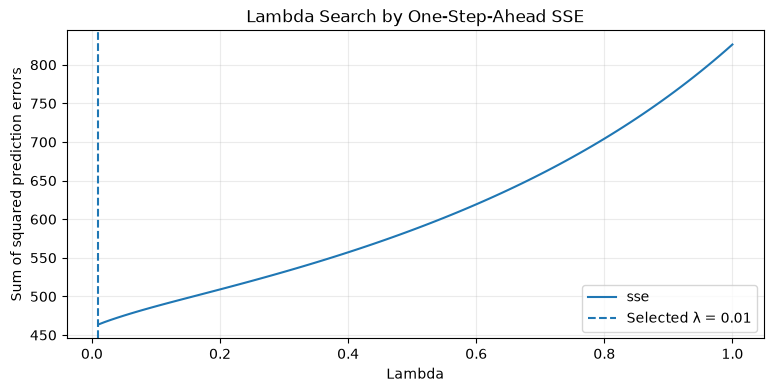

In [10]:
from src.ewma import estimate_lambda

best_lambda, lambda_results = estimate_lambda(
    training_data["x"].to_numpy()
)

print(f"Best lambda: {best_lambda:.2f}")

ax = lambda_results.plot(
    x="lambda",
    y="sse",
    figsize=(9, 4),
    title="Lambda Search by One-Step-Ahead SSE",
    legend=False,
)

ax.axvline(
    best_lambda,
    linestyle="--",
    label=f"Selected λ = {best_lambda:.2f}",
)

ax.set_xlabel("Lambda")
ax.set_ylabel("Sum of squared prediction errors")
ax.legend()
ax.grid(alpha=0.25)

In [11]:
from src.evaluation import evaluate_stage_1_detection
from src.ewma import (
    SD_EWMA_Config,
    estimate_lambda,
    fit_sd_ewma,
    run_sd_ewma,
)

In [12]:
from time import perf_counter


detector_config = SD_EWMA_Config(
    lambda_value=training_result.lambda_value,
    variance_smoothing=0.05,
    control_limit_multiplier=3.0,
)

start_time = perf_counter()

stage_1_results = run_sd_ewma(
    values=testing_data["x"].to_numpy(),
    times=testing_data["time"].to_numpy(),
    initial_z=training_result.final_z,
    initial_error_variance=training_result.error_variance,
    config=detector_config,
)

computation_time_seconds = (
    perf_counter() - start_time
)

print(
    f"SD-EWMA computation time: "
    f"{computation_time_seconds:.6f} seconds"
)

stage_1_results.head()

SD-EWMA computation time: 0.008197 seconds


,time,x,prediction,ewma,error,lcl,ucl,stage_1_alarm
0,500,3.363862,-0.012404,0.021359,3.376266,-2.901380,2.876572,1
1,501,2.895185,0.021359,0.050097,2.873826,-3.592296,3.635014,0
2,502,1.280520,0.050097,0.062401,1.230423,-3.965133,4.065327,0
3,503,0.497497,0.062401,0.066752,0.435095,-3.937254,4.062056,0
4,504,-0.964529,0.066752,0.056439,-1.031281,-3.842540,3.976045,0


In [13]:
shift_times = gaussian_stream.loc[
    gaussian_stream["true_shift"] == 1,
    "time",
].to_numpy()

if len(shift_times) != 1:
    raise ValueError(
        "Expected exactly one true shift point."
    )

true_shift_time = int(shift_times[0])

metrics = evaluate_stage_1_detection(
    results=stage_1_results,
    true_shift_time=true_shift_time,
    computation_time_seconds=computation_time_seconds,
)

metrics

DetectionMetrics(false_positive_count=0, false_positive_rate=nan, false_negative_count=0, shift_detected=True, first_detection_time=500, recognition_capability_index=0, computation_time_seconds=0.00819700000101875)

In [14]:
metrics_summary = pd.DataFrame([{
    "method": "SD-EWMA",
    "false_positive_count": (
        metrics.false_positive_count
    ),
    "false_positive_rate_percent": (
        metrics.false_positive_rate * 100
    ),
    "false_negative_count": (
        metrics.false_negative_count
    ),
    "shift_detected": metrics.shift_detected,
    "first_detection_time": (
        metrics.first_detection_time
    ),
    "rci": (
        metrics.recognition_capability_index
    ),
    "computation_time_seconds": (
        metrics.computation_time_seconds
    ),
}])

metrics_summary

,method,false_positive_count,false_positive_rate_percent,false_negative_count,shift_detected,first_detection_time,rci,computation_time_seconds
0,SD-EWMA,0,NaN,0,True,500,0,0.008197
